# Defining Measurement Risks in Dual-Color Application

### Overview

The completed spectrometer-based system was next evaluated under a realistic dual-color measurement scenario using GCaMP6f and jRGECO1a.  
Before simultaneous recording could be interpreted reliably, two practical risks had to be characterized: spectral overlap between the green and red sensors, and excitation-dependent signal instability during prolonged recording.

This stage therefore focused on defining the measurement conditions that could compromise dual-color interpretation before the system was applied to actual simultaneous recordings.

### Why Dual-Color Application Required Validation

Many experiments require simultaneous observation of more than one signal because behavior is shaped by interactions across multiple neural processes rather than by a single pathway alone. For that reason, the completed system needed to be tested under a dual-color measurement condition rather than only under single-channel operation.

GCaMP6f and jRGECO1a were selected as a representative green/red sensor pair for this validation step. This combination provided a practical validation case for determining whether the system could resolve overlapping fluorescence signals while maintaining sufficient signal stability under realistic dual-color recording conditions.

### Risk 1: Spectral Overlap Between Green and Red Sensors

The first risk examined in dual-color application was whether fluorescence from the green sensor could extend into the red detection range. If the two emission profiles were not fully isolated, signal detected in the red channel could no longer be interpreted as exclusively originating from the red sensor.

This question had to be addressed before simultaneous green/red recording could be considered reliable.

### Examining Spectral Separation Between the Two Sensors

The emission spectra of GCaMP6f and jRGECO1a were first examined separately to determine whether their fluorescence profiles could interfere with each other during dual-color recording. Although the two sensors are commonly treated as green and red channels, their emission spectra are not fully isolated across the entire wavelength range.

This initial comparison was therefore used to determine whether the red detection range could contain signal contributions originating from the green sensor.

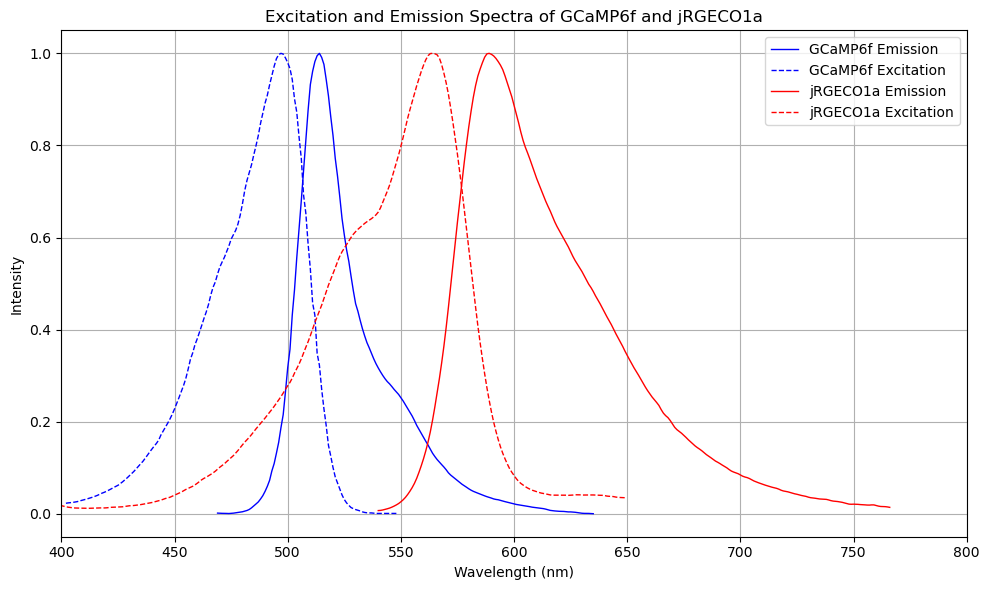

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
REFERENCE_DIR = PROJECT_ROOT / "data" / "reference"

# Define repository-relative paths for the reference excitation and emission spectra
gcamp_path = REFERENCE_DIR / "GCaMP6f_emission.csv"
jrgeco_path = REFERENCE_DIR / "jRGECO1a_emission.csv"

# Load the spectral reference datasets used to evaluate cross-channel overlap under the representative dual-color sensor pair
gcamp = pd.read_csv(gcamp_path)
jrgeco = pd.read_csv(jrgeco_path)

# Extract excitation and emission profiles while excluding empty entries
# Column 2 contains the excitation profile for GCaMP6f
gcamp_ex_mask = gcamp.iloc[:, 1].notna()
gcamp_ex_wl = gcamp.loc[gcamp_ex_mask, 'wavelength']
gcamp_ex = gcamp.loc[gcamp_ex_mask].iloc[:, 1]

# The third column contains emission values for GCaMP6f
gcamp_em_mask = gcamp.iloc[:, 2].notna()
gcamp_em_wl = gcamp.loc[gcamp_em_mask, 'wavelength']
gcamp_em = gcamp.loc[gcamp_em_mask].iloc[:, 2]

jrgeco_em_mask = jrgeco.iloc[:, 1].notna()
jrgeco_em_wl = jrgeco.loc[jrgeco_em_mask, 'wavelength']
jrgeco_em = jrgeco.loc[jrgeco_em_mask].iloc[:, 1]

jrgeco_ex_mask = jrgeco.iloc[:, 2].notna()
jrgeco_ex_wl = jrgeco.loc[jrgeco_ex_mask, 'wavelength']
jrgeco_ex = jrgeco.loc[jrgeco_ex_mask].iloc[:, 2]

# Plot the excitation and emission spectra to inspect the degree of spectral separation between the two sensors
plt.figure(figsize=(10, 6))
plt.plot(gcamp_em_wl, gcamp_em, 'b-', label='GCaMP6f Emission', linewidth=1)
plt.plot(gcamp_ex_wl, gcamp_ex, 'b--', label='GCaMP6f Excitation', linewidth=1)
plt.plot(jrgeco_em_wl, jrgeco_em, 'r-', label='jRGECO1a Emission', linewidth=1)
plt.plot(jrgeco_ex_wl, jrgeco_ex, 'r--', label='jRGECO1a Excitation', linewidth=1)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.title('Excitation and Emission Spectra of GCaMP6f and jRGECO1a')
plt.legend(loc='upper right')
plt.grid(True)
plt.xlim(400, 800)
plt.tight_layout()
plt.show()


### Visualizing the Spectral Overlap

The overlap region became particularly important near 590 nm, which corresponds to the principal detection range of the red sensor. This raised a critical concern because fluorescence detected in that range could no longer be interpreted with confidence as purely red-sensor signal.

Quantitative analysis of the 590 nm region confirmed that the measured intensity could not be treated as exclusively red-channel fluorescence. Even a modest contribution from the green sensor becomes problematic in dual-color experiments because fluctuations observed in the red range may reflect mixed spectral contributions rather than sensor-specific activity.

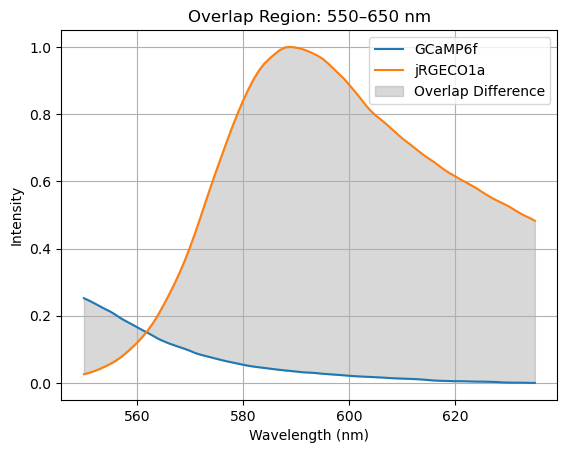

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Merge the emission spectra so that the shared wavelength interval can be compared directly on a common wavelength axis
merged = pd.merge(
    gcamp_em_wl.to_frame(name='wavelength').assign(gcamp=gcamp_em.values),
    jrgeco_em_wl.to_frame(name='wavelength').assign(jrgeco=jrgeco_em.values),
    on='wavelength'
)

# Restrict the comparison to 550–650 nm, which contains the relevant overlap region for potential red-channel contamination
range_mask = (merged['wavelength'] >= 550) & (merged['wavelength'] <= 650)
overlap_df = merged[range_mask].copy()

# Compute the wavelength-wise difference between the two emission profiles across the overlap region
overlap_df['difference'] = overlap_df['gcamp'] - overlap_df['jrgeco']
overlap_df['abs_diff'] = np.abs(overlap_df['difference'])

# Visualize the overlap region to assess whether the green sensor contributes measurable signal near the red detection range
plt.plot(overlap_df['wavelength'], overlap_df['gcamp'], label='GCaMP6f')
plt.plot(overlap_df['wavelength'], overlap_df['jrgeco'], label='jRGECO1a')
plt.fill_between(overlap_df['wavelength'], overlap_df['gcamp'], overlap_df['jrgeco'], 
                 color='gray', alpha=0.3, label='Overlap Difference')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.title('Overlap Region: 550–650 nm')
plt.legend()
plt.grid(True)
plt.show()

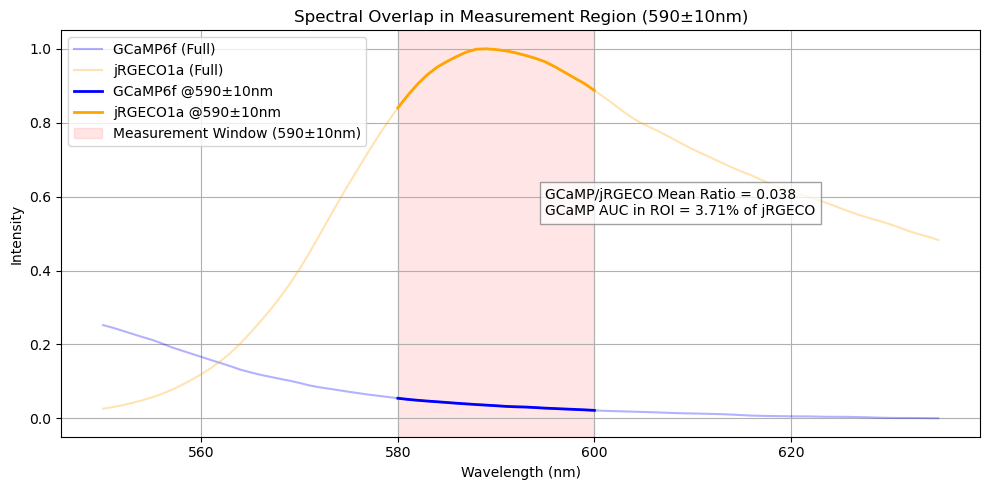

In [6]:
# Define a region of interest around 590 nm because this interval
# corresponds to the principal red-channel measurement range
roi_center = 590
roi_width = 10
roi_min, roi_max = roi_center - roi_width, roi_center + roi_width

roi_mask = (overlap_df['wavelength'] >= roi_min) & (overlap_df['wavelength'] <= roi_max)
roi_gc = overlap_df.loc[roi_mask, 'gcamp']
roi_jr = overlap_df.loc[roi_mask, 'jrgeco']
roi_ratio = roi_gc / roi_jr

mean_ratio = roi_ratio.mean()
max_ratio = roi_ratio.max()

# Compute the area under the curve for both spectra within the 590 ± 10 nm measurement window
from numpy import trapz
gcamp_auc_roi = trapz(roi_gc, x=overlap_df.loc[roi_mask, 'wavelength'])
jrgeco_auc_roi = trapz(roi_jr, x=overlap_df.loc[roi_mask, 'wavelength'])

# Estimate the relative magnitude of GCaMP6f-derived signal within the red-channel measurement window
gcamp_percent_vs_jrgeco_in_roi = (gcamp_auc_roi / jrgeco_auc_roi) * 100

# ---------------------------------------------------------
plt.figure(figsize=(10, 5))

# Plot the full spectral traces with reduced opacity to provide context outside the measurement window
plt.plot(overlap_df['wavelength'], overlap_df['gcamp'], color='blue', alpha=0.3, label='GCaMP6f (Full)')
plt.plot(overlap_df['wavelength'], overlap_df['jrgeco'], color='orange', alpha=0.3, label='jRGECO1a (Full)')

# Emphasize the spectral segments that fall within the red-channel measurement window
plt.plot(overlap_df['wavelength'][roi_mask], roi_gc, color='blue', linewidth=2, label='GCaMP6f @590±10nm')
plt.plot(overlap_df['wavelength'][roi_mask], roi_jr, color='orange', linewidth=2, label='jRGECO1a @590±10nm')

# Highlight the 590 ± 10 nm interval used for red-channel interpretation
plt.axvspan(roi_min, roi_max, color='red', alpha=0.1, label='Measurement Window (590±10nm)')

# Plotting calculated numbers
info_text = (
    f"GCaMP/jRGECO Mean Ratio = {mean_ratio:.3f}\n"
    f"GCaMP AUC in ROI = {gcamp_percent_vs_jrgeco_in_roi:.2f}% of jRGECO"
)
plt.text(roi_center + 5, 0.55, info_text, fontsize=10, color='black',
         bbox=dict(facecolor='white', alpha=0.75, edgecolor='gray'))

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.title('Spectral Overlap in Measurement Region (590±10nm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Risk 2: Excitation-Dependent Signal Instability

Reliable dual-color measurement required solving not only spectral ambiguity, but also long-term signal stability during continuous recording.  
Signal separation alone would not be sufficient if one sensor lost intensity rapidly under sustained excitation.

The next step was therefore to determine whether the green and red channels showed comparable photostability under the same recording condition, and whether excitation power had to be adjusted to preserve usable signal quality over longer sessions.

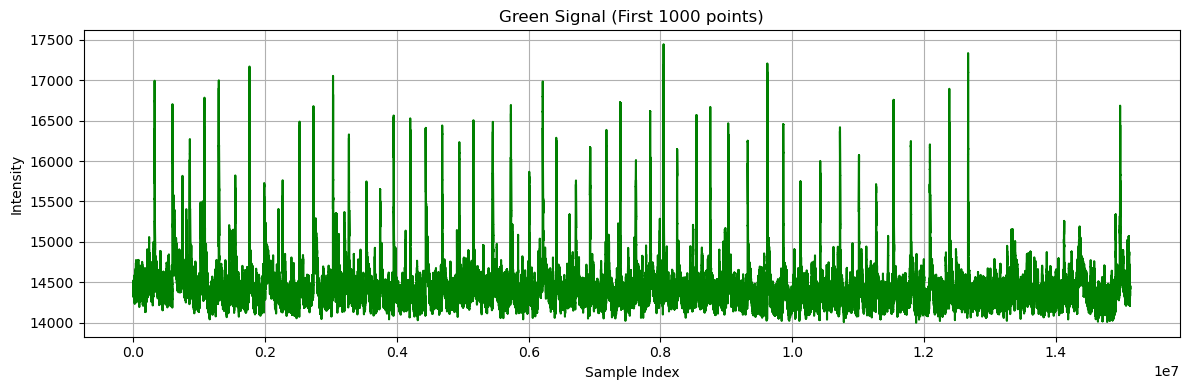

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PHOTOBLEACH_DIR = PROJECT_ROOT / "data" / "photobleaching"

# Load representative 25 µW green-channel recording for initial stability inspection
mat_file = PHOTOBLEACH_DIR / "25uw_green.mat"
mat_data = loadmat(mat_file)

# Remove MATLAB metadata fields that are not part of the recorded signal
clean_data = {k: v for k, v in mat_data.items() if not k.startswith('__')}

# Extract the recorded signal and convert it to a 1D array
signal = clean_data['spec1'].flatten()

# Plot the raw green-channel trace
plt.figure(figsize=(12, 4))
plt.plot(signal, color='green')
plt.title("Green Signal (First 1000 points)")
plt.xlabel("Sample Index")
plt.ylabel("Intensity")
plt.grid(True)
plt.tight_layout()
plt.show()


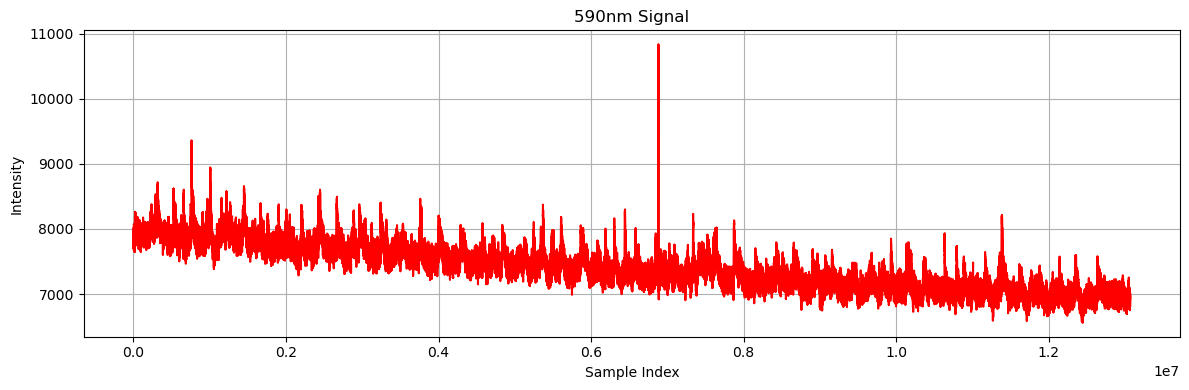

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PHOTOBLEACH_DIR = PROJECT_ROOT / "data" / "photobleaching"

# Load representative 25 µW red-channel recording for initial stability inspection
mat_file = PHOTOBLEACH_DIR / "25uw_red.mat"
mat_data = loadmat(mat_file)

clean_data = {k: v for k, v in mat_data.items() if not k.startswith('__')}

# Extract the recorded signal and convert it to a 1D array
signal = clean_data['spec2'].flatten()

# Plot the raw red-channel trace
plt.figure(figsize=(12, 4))
plt.plot(signal, color='red')
plt.title("590nm Signal")
plt.xlabel("Sample Index")
plt.ylabel("Intensity")
plt.grid(True)
plt.tight_layout()
plt.show()


### Initial Comparison of Green and Red Signal Stability

Raw-intensity inspection under the same excitation condition showed different stability profiles for the two channels. The green signal remained comparatively stable, whereas the red signal showed a more pronounced loss of intensity over time.

Comparison of the downsampled long-recording traces confirmed that the red channel was more susceptible to intensity loss during recordings lasting approximately 20–30 minutes. This result indicated that excitation power could not be selected only for signal visibility, but also had to be optimized for long-term recording stability.

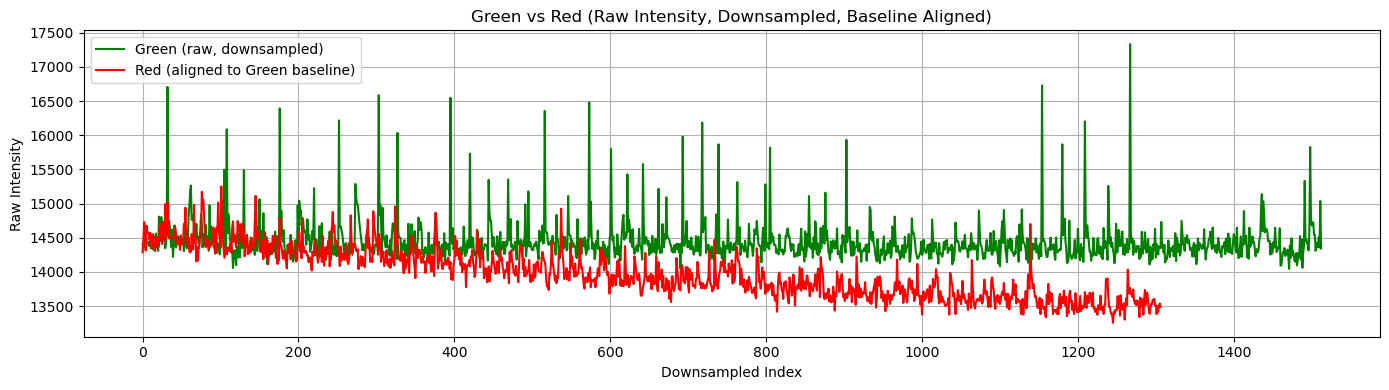

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PHOTOBLEACH_DIR = PROJECT_ROOT / "data" / "photobleaching"

# Load representative green and red recordings acquired under the same excitation condition
green_file = PHOTOBLEACH_DIR / "25uw_green.mat"
red_file = PHOTOBLEACH_DIR / "25uw_red.mat"

green_raw = loadmat(green_file)
red_raw   = loadmat(red_file)

green_clean = {k: v for k, v in green_raw.items() if not k.startswith('__')}
red_clean   = {k: v for k, v in red_raw.items() if not k.startswith('__')}

# Extract usable signal arrays from the MATLAB files
def extract_signal(mat_dict):
    for k, v in mat_dict.items():
        if isinstance(v, np.ndarray) and v.size > 1000:
            return v.flatten()
    raise ValueError("No usable signal found")

green = extract_signal(green_clean)
red   = extract_signal(red_clean)

# Downsample the long-session traces for compact visual comparison
DS = 10000
green_ds = green[::DS]
red_ds   = red[::DS]

# Align the starting baseline so that relative signal decay can be compared directly
N_BASE = 50  # 처음 50 포인트 평균 사용 (필요하면 조절)
base_g = np.mean(green_ds[:N_BASE])
base_r = np.mean(red_ds[:N_BASE])

# Shift the red trace to the green baseline for direct visual comparison
red_aligned = red_ds + (base_g - base_r)

# Plot downsampled traces after baseline alignment
plt.figure(figsize=(14, 4))
plt.plot(green_ds,      color='green', label='Green (raw, downsampled)')
plt.plot(red_aligned,   color='red',   label='Red (aligned to Green baseline)')

plt.title("Green vs Red (Raw Intensity, Downsampled, Baseline Aligned)")
plt.xlabel("Downsampled Index")
plt.ylabel("Raw Intensity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Green % change (signed): -0.4237647258242224
Red % change (signed): -10.32849020846494


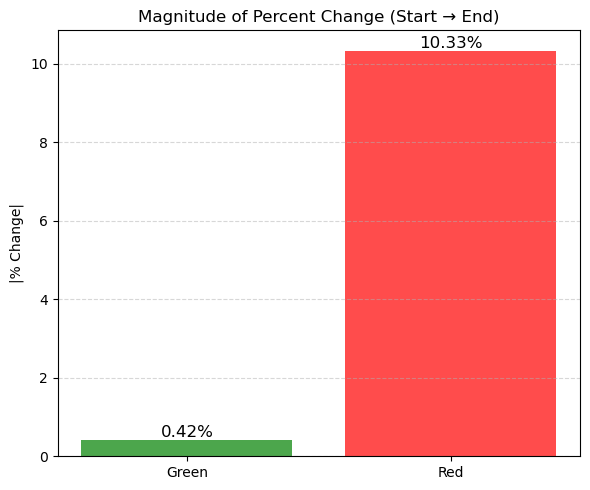

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PHOTOBLEACH_DIR = PROJECT_ROOT / "data" / "photobleaching"

# Load representative green and red recordings for quantitative stability comparison
green_file = PHOTOBLEACH_DIR / "25uw_green.mat"
red_file = PHOTOBLEACH_DIR / "25uw_red.mat"

green_raw = loadmat(green_file)
red_raw   = loadmat(red_file)

green_clean = {k: v for k, v in green_raw.items() if not k.startswith('__')}
red_clean   = {k: v for k, v in red_raw.items() if not k.startswith('__')}

# Extract usable signal arrays from the MATLAB files
def extract_signal(mat_dict):
    for k, v in mat_dict.items():
        if isinstance(v, np.ndarray) and v.size > 1000:
            return v.flatten()
    raise ValueError("No usable signal found")

green = extract_signal(green_clean)
red   = extract_signal(red_clean)

# Downsample the long-session traces before comparing start-to-end change
DS = 10000
green_ds = green[::DS]
red_ds   = red[::DS]

# Compute signed percentage change from the start to the end of each trace
g0, g_end = green_ds[0], green_ds[-1]
r0, r_end = red_ds[0], red_ds[-1]

green_pct_change = (g_end - g0) / g0 * 100
red_pct_change   = (r_end - r0) / r0 * 100

print("Green % change (signed):", green_pct_change)
print("Red % change (signed):",   red_pct_change)

# Use absolute magnitude only for the summary bar plot
labels = ["Green", "Red"]
pct_values = [abs(green_pct_change), abs(red_pct_change)]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, pct_values, color=['green', 'red'], alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}%", ha='center', va='bottom', fontsize=12)

plt.title("Magnitude of Percent Change (Start → End)")
plt.ylabel("|% Change|")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Power-Dependent Stability Assessment

Because the red signal was more susceptible to photobleaching, excitation-power-dependent stability had to be examined more systematically. Additional recordings were therefore compared across multiple power settings to identify the strongest excitation level that still preserved acceptable long-term stability.  
The comparison showed that jRGECO1a remained relatively stable at lower power settings, but exhibited clear photobleaching at higher excitation levels.
  
Based on this tradeoff, 25 µW was selected as the practical operating condition because it provided the strongest usable excitation without introducing prominent signal degradation in the red channel. Because GCaMP6f remained stable across the tested range, the final operating condition was determined primarily by the photostability constraint of jRGECO1a.

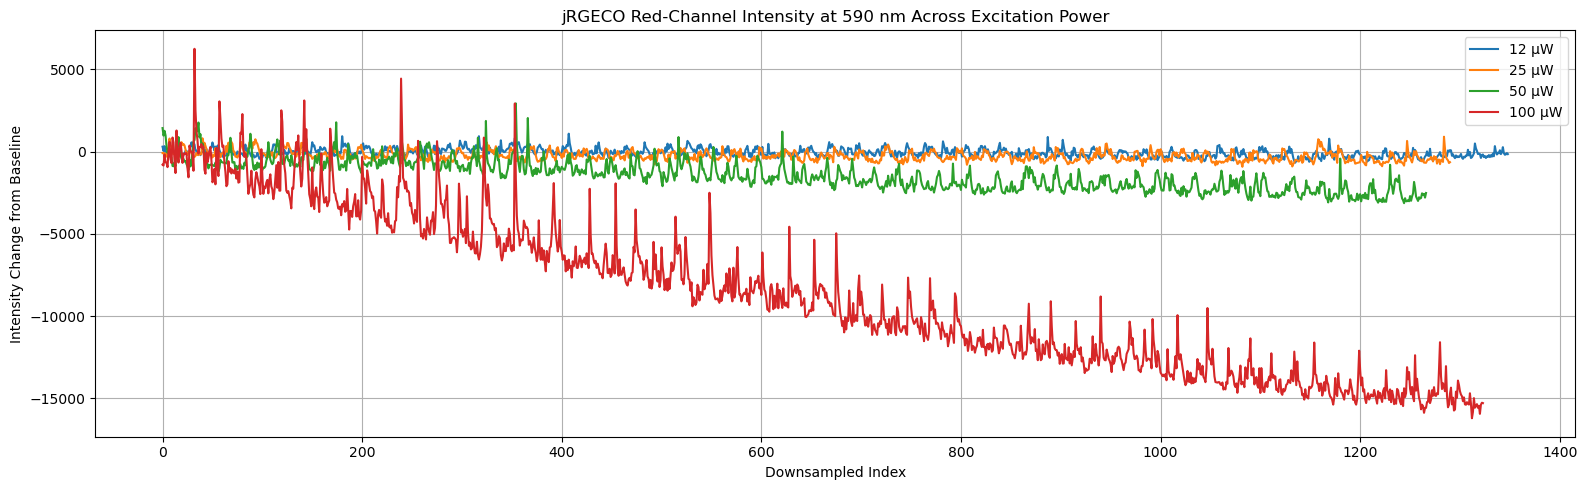

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PHOTOBLEACH_DIR = PROJECT_ROOT / "data" / "photobleaching"
RED_POWER_DIR = PHOTOBLEACH_DIR / "red_power"

# Define repository-relative paths for the red-power comparison datasets.

# Define a reusable helper for extracting the recorded signal array from MATLAB files.
def extract_signal(mat_dict):
    for k, v in mat_dict.items():
        if isinstance(v, np.ndarray) and v.size > 1000:
            return v.flatten()
    raise ValueError("No usable signal found in MAT file.")

file_dict = {
    "12 µW": "jR_12uw_590nm.mat",
    "25 µW": "jR_25uw_590nm.mat",
    "50 µW": "jR_50uw_590nm.mat",
    "100 µW": "jR_100uw_590nm.mat"
}

# Load each power-condition recording, downsample the trace, and align the starting baseline for direct comparison.
DS = 10000   # Downsampling factor for compact long-session visualization.
N_BASE = 50  # Number of initial samples used for baseline averaging after downsampling.

signals = {}  # Store the processed trace for each excitation-power condition.

for label, fname in file_dict.items():
    mat_path = RED_POWER_DIR / fname
    data_raw = loadmat(mat_path)

    # Remove MATLAB metadata fields that are not part of the recorded signal.
    data_clean = {k: v for k, v in data_raw.items() if not k.startswith("__")}

    # Extract the recorded signal.
    sig = extract_signal(data_clean)

    # Downsample the trace for long-session comparison.
    sig_ds = sig[::DS]

    # Align the trace to the initial baseline window so that decay patterns
    # can be compared directly across excitation-power conditions.
    base = np.mean(sig_ds[:N_BASE])
    sig_aligned = sig_ds - base

    signals[label] = sig_aligned

# Plot the processed red-channel traces across excitation-power conditions.
plt.figure(figsize=(16, 5))

for label, sig in signals.items():
    plt.plot(sig, label=label)

plt.title("jRGECO Red-Channel Intensity at 590 nm Across Excitation Power")
plt.xlabel("Downsampled Index")
plt.ylabel("Intensity Change from Baseline")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Outcome

This stage moved the project from system construction to application-readiness testing.  
The results showed that dual-color measurement could not be assumed to be reliable by default, because spectral overlap introduced ambiguity in the red channel and excitation power affected long-term signal stability.

By identifying both sources of measurement risk and defining an operating condition that preserved signal quality, this stage established the experimental basis for applying the completed system to simultaneous green/red recordings.